In [1]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt

In [74]:
# Load your pantry data
pantries = pd.read_csv("pantries.csv")

In [3]:

pantries_gdf = gpd.GeoDataFrame(pantries, geometry=gpd.points_from_xy(pantries.Long, pantries.Lat), crs='EPSG:4326')

# Convert to a projected coordinate system (for miles)
pantries_gdf = pantries_gdf.to_crs(epsg=32618)  # UTM zone for NY area

# Create a 6-mile buffer (~9656 meters)
pantries_gdf['buffer'] = pantries_gdf.buffer(9656)

# --- STEP 3. Convert to a projected coordinate system (for distance in meters) ---
# UTM Zone 18N covers Tompkins County area
gdf = pantries_gdf.to_crs(epsg=32618)

# --- STEP 4. Define parameters ---
radius_meters = 6 * 1609.34   # 6 miles in meters
decay_rate = 0.765            # 23.5% decrease per mile

def decay(distance_miles):
    return decay_rate ** distance_miles

# --- STEP 5. Create an expanded grid around all pantries for visualization ---
x_min, y_min, x_max, y_max = gdf.total_bounds

# Expand bounds by the 6-mile radius (in meters)
buffer = 6 * 1609.34
x_min -= buffer
x_max += buffer
y_min -= buffer
y_max += buffer

# Generate grid points
grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300))

# Flatten to points
points = [Point(x, y) for x, y in zip(grid_x.flatten(), grid_y.flatten())]

# --- STEP 6. Compute probability field for ONE pantry as example ---
pantry_idx = 3  #! change this to visualize other pantries
pantry_point = gdf.geometry.iloc[pantry_idx]

# Compute distances in miles
distances = np.array([pantry_point.distance(p)/1609.34 for p in points])
probabilities = decay(distances)

# Clip to 6-mile radius
probabilities[distances > 6] = 0



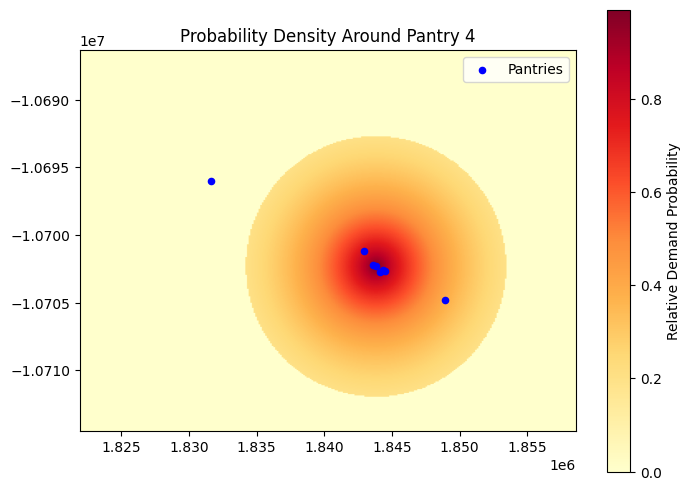

In [ ]:
# --- STEP 7. Visualize ---
plt.figure(figsize=(8, 6))
plt.imshow(
    probabilities.reshape(grid_x.shape),
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd'
)
plt.colorbar(label='Relative Demand Probability')
plt.scatter(gdf.geometry.x, gdf.geometry.y, color='blue', s=20, label='Pantries')
plt.title(f"Probability Density Around Pantry {gdf['Pantry'].iloc[pantry_idx]}")
plt.legend()
plt.show()

In [75]:
def dist_pantry_prob(pantry):
    pantries_gdf = gpd.GeoDataFrame(pantries, geometry=gpd.points_from_xy(pantries.Long, pantries.Lat), crs='EPSG:4326')

    # Convert to a projected coordinate system (for miles)
    pantries_gdf = pantries_gdf.to_crs(epsg=32618)  # UTM zone for NY area

    # Create a 6-mile buffer (~9656 meters)
    pantries_gdf['buffer'] = pantries_gdf.buffer(9656)

    # --- STEP 3. Convert to a projected coordinate system (for distance in meters) ---
    # UTM Zone 18N covers Tompkins County area
    gdf = pantries_gdf.to_crs(epsg=32618)

    # --- STEP 4. Define parameters ---
    radius_meters = 6 * 1609.34   # 6 miles in meters
    decay_rate = 0.765            # 23.5% decrease per mile

    def decay(distance_miles):
        return decay_rate ** distance_miles

    # --- STEP 5. Create an expanded grid around all pantries for visualization ---
    x_min, y_min, x_max, y_max = gdf.total_bounds

    # Expand bounds by the 6-mile radius (in meters)
    buffer = 6 * 1609.34
    x_min -= buffer
    x_max += buffer
    y_min -= buffer
    y_max += buffer

    # Generate grid points
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300))

    # Flatten to points
    points = [Point(x, y) for x, y in zip(grid_x.flatten(), grid_y.flatten())]

    # --- STEP 6. Compute probability field for ONE pantry as example ---
    pantry_point = gdf.geometry.iloc[pantry]

    # Compute distances in miles
    distances = np.array([pantry_point.distance(p)/1609.34 for p in points])
    probabilities = decay(distances)

    # Clip to 6-mile radius
    probabilities[distances > 6] = 0

    # --- STEP 7. Visualize ---
    plt.figure(figsize=(8, 6))
    plt.imshow(
        probabilities.reshape(grid_x.shape),
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='YlOrRd'
    )
    plt.colorbar(label='Relative Demand Probability')
    plt.scatter(gdf.geometry.x, gdf.geometry.y, color='blue', s=20, label='Pantries')
    plt.title(f"Probability Density Around Pantry {gdf['Pantry'].iloc[pantry]}")
    plt.legend()
    plt.show()

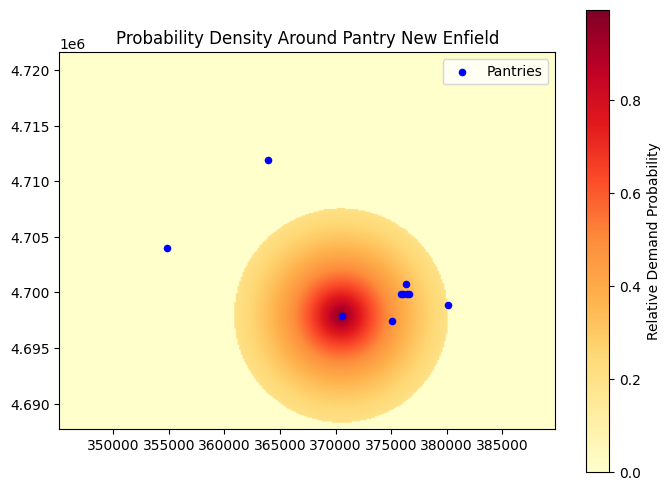

In [76]:
dist_pantry_prob(0)

In [77]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

# --- Load pantry CSV ---
pantries = pd.read_csv("pantries.csv")
gdf_pantry = gpd.GeoDataFrame(
    pantries,
    geometry=gpd.points_from_xy(pantries.Long, pantries.Lat),
    crs="EPSG:4326"
).to_crs(32618)

# --- Load block CSV ---
blocks = pd.read_csv("blocks.csv")
gdf_blocks = gpd.GeoDataFrame(
    blocks,
    geometry=gpd.points_from_xy(blocks.lon, blocks.lat),
    crs="EPSG:4326"
).to_crs(32618)


In [78]:
decay_rate = 0.765  # 23.5% reduction per mile

def decay(d_miles):
    return decay_rate ** d_miles


In [79]:
pantry_ids = gdf_pantry["Pantry"].tolist()

for pantry_id in pantry_ids:
    pantry_point = gdf_pantry.loc[gdf_pantry["Pantry"] == pantry_id].geometry.values[0]

    # distance in miles
    distances = gdf_blocks.geometry.distance(pantry_point) / 1609.34

    # apply decay
    gdf_blocks[f"p_raw_{pantry_id}"] = decay(distances)


In [80]:
raw_cols = [f"p_raw_{pid}" for pid in pantry_ids]
raw_sum = gdf_blocks[raw_cols].sum(axis=1)

for pid in pantry_ids:
    gdf_blocks[f"p_norm_{pid}"] = gdf_blocks[f"p_raw_{pid}"] / raw_sum


In [81]:
for pid in pantry_ids:
    gdf_blocks[f"demand_{pid}"] = gdf_blocks["need_score"] * gdf_blocks[f"p_norm_{pid}"]


In [82]:
pantry_demand = {
    pid: gdf_blocks[f"demand_{pid}"].sum()
    for pid in pantry_ids
}

print(pantry_demand)


{'New Enfield': 20.266335088361856, 'A': 30.06626920443144, 'B': 37.03150099817352, 'C': 37.60047255069844, 'D': 39.066487646194005, 'E': 39.499697681983065, 'F': 38.88063502641764, 'G': 38.97696687631586, 'Extra A': 4.018700186214401, 'Extra B': 11.60422413450576}


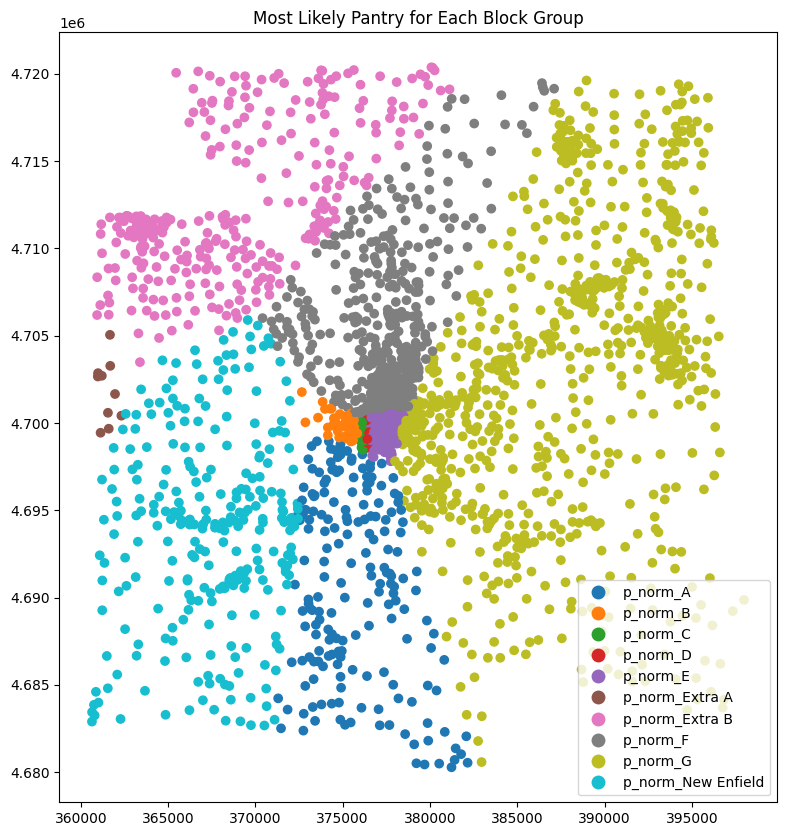

In [83]:
gdf_blocks["best_pantry"] = gdf_blocks[[f"p_norm_{pid}" for pid in pantry_ids]].idxmax(axis=1)
# gdf_blocks["best_pantry"] = gdf_blocks["best_pantry"].str.extract("(\d+)").astype(int)
import matplotlib.pyplot as plt

gdf_blocks.plot(
    column="best_pantry",
    cmap="tab10",
    legend=True,
    figsize=(10, 10)
)
plt.title("Most Likely Pantry for Each Block Group")
plt.show()


In [84]:
gdf_blocks.to_file("blocks.geojson", driver="GeoJSON")
